# Análisis de SBOM (Software Bill of Materials)

Análisis del inventario de componentes generado por **Syft** para cada repositorio.  
El objetivo es identificar los **tipos de paquetes**, **ecosistemas**, **lenguajes** y **licencias** presentes, que servirán de base para el análisis de vulnerabilidades de dependencias.

**Archivo fuente:** `{repo}-sbom.json` (formato Syft JSON)

In [9]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RESULTS_DIR = Path('../../data/results')
SBOM_FILES  = sorted(RESULTS_DIR.glob('*-sbom.json'))

assert SBOM_FILES, 'No se encontraron archivos SBOM. Ejecuta el pipeline primero.'
print(f'Archivos SBOM encontrados: {len(SBOM_FILES)}')
for f in SBOM_FILES:
    print(' -', f.name)

Archivos SBOM encontrados: 10
 - body-parser-sbom.json
 - compression-sbom.json
 - cookie-parser-sbom.json
 - cors-sbom.json
 - csurf-sbom.json
 - express-sbom.json
 - expressjs.com-sbom.json
 - morgan-sbom.json
 - multer-sbom.json
 - session-sbom.json


## 1. Carga y normalización de artefactos

In [10]:
registros = []
for sbom_file in SBOM_FILES:
    repo = sbom_file.name.replace('-sbom.json', '')
    data = json.loads(sbom_file.read_text(encoding='utf-8'))

    source_info = data.get('source', {})
    distro_info = data.get('distro', {})

    for artifact in data.get('artifacts', []):
        licencias = artifact.get('licenses', [])
        if licencias and isinstance(licencias[0], dict):
            licencias = [lic.get('value', '') for lic in licencias]

        registros.append({
            'repositorio':  repo,
            'nombre':       artifact.get('name', ''),
            'version':      artifact.get('version', ''),
            'tipo':         artifact.get('type', 'desconocido'),
            'lenguaje':     artifact.get('language') or 'sin lenguaje',
            'encontrado_por': artifact.get('foundBy', ''),
            'licencias':    ', '.join(licencias) if licencias else 'sin licencia',
            'purl':         artifact.get('purl', ''),
            'n_cpes':       len(artifact.get('cpes', [])),
            'n_ubicaciones': len(artifact.get('locations', [])),
        })

df = pd.DataFrame(registros)
print(f'Total de componentes: {len(df)}')
df.head()

Total de componentes: 673


,repositorio,nombre,version,tipo,lenguaje,encontrado_por,licencias,purl,n_cpes,n_ubicaciones
0,body-parser,actions/checkout,v6.0.2,github-action,sin lenguaje,github-actions-usage-cataloger,sin licencia,pkg:github/actions/checkout@v6.0.2,1,1
1,body-parser,actions/checkout,v6.0.2,github-action,sin lenguaje,github-actions-usage-cataloger,sin licencia,pkg:github/actions/checkout@v6.0.2,1,1
2,body-parser,actions/checkout,v6.0.2,github-action,sin lenguaje,github-actions-usage-cataloger,sin licencia,pkg:github/actions/checkout@v6.0.2,1,1
3,body-parser,actions/download-artifact,v8.0.1,github-action,sin lenguaje,github-actions-usage-cataloger,sin licencia,pkg:github/actions/download-artifact@v8.0.1,6,1
4,body-parser,actions/setup-node,v6.4.0,github-action,sin lenguaje,github-actions-usage-cataloger,sin licencia,pkg:github/actions/setup-node@v6.4.0,6,1


## 2. Distribución por tipo de paquete

Tipos de paquete identificados:
tipo
npm              555
github-action    118


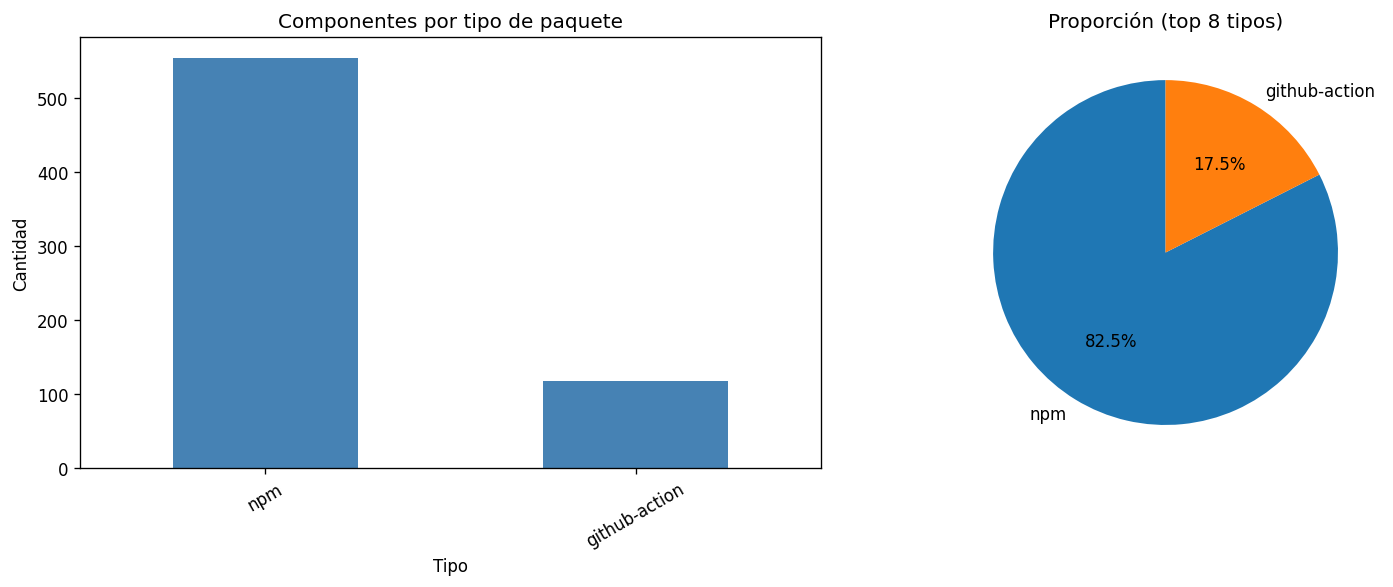

In [11]:
tipo_counts = df['tipo'].value_counts()
print('Tipos de paquete identificados:')
print(tipo_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tipo_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Componentes por tipo de paquete')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=30)

top_n = tipo_counts.head(8)
axes[1].pie(top_n, labels=top_n.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción (top 8 tipos)')

plt.tight_layout()
plt.show()

## 3. Distribución por lenguaje / ecosistema

Lenguajes/ecosistemas detectados:
lenguaje
javascript      555
sin lenguaje    118


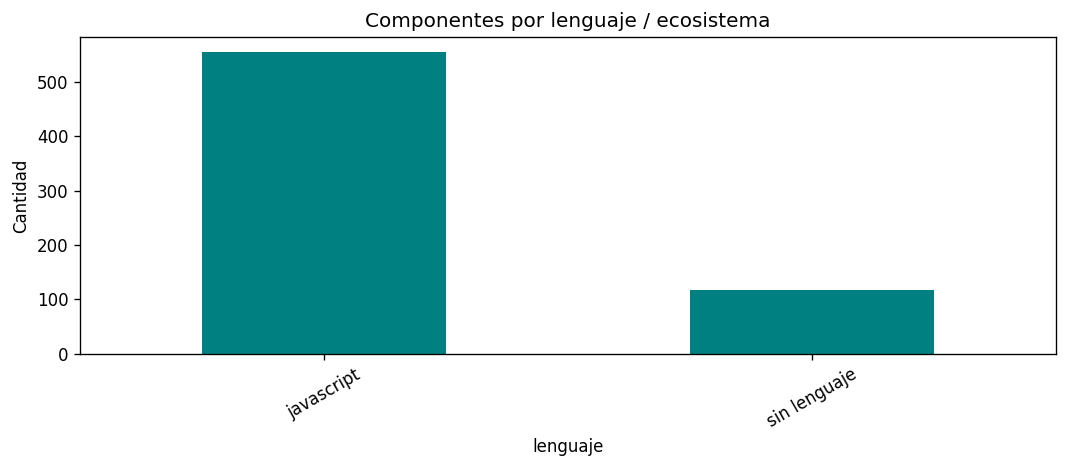

In [12]:
lang_counts = df['lenguaje'].value_counts()
print('Lenguajes/ecosistemas detectados:')
print(lang_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
lang_counts.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Componentes por lenguaje / ecosistema')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Componentes por repositorio

,total_componentes,tipos_distintos,lenguajes_distintos,con_licencia
repositorio,,,,
expressjs.com,584,2,2,487
express,17,1,1,0
body-parser,12,1,1,0
compression,12,1,1,0
session,11,1,1,0
morgan,10,1,1,0
cookie-parser,9,1,1,0
cors,9,1,1,0
multer,9,1,1,0


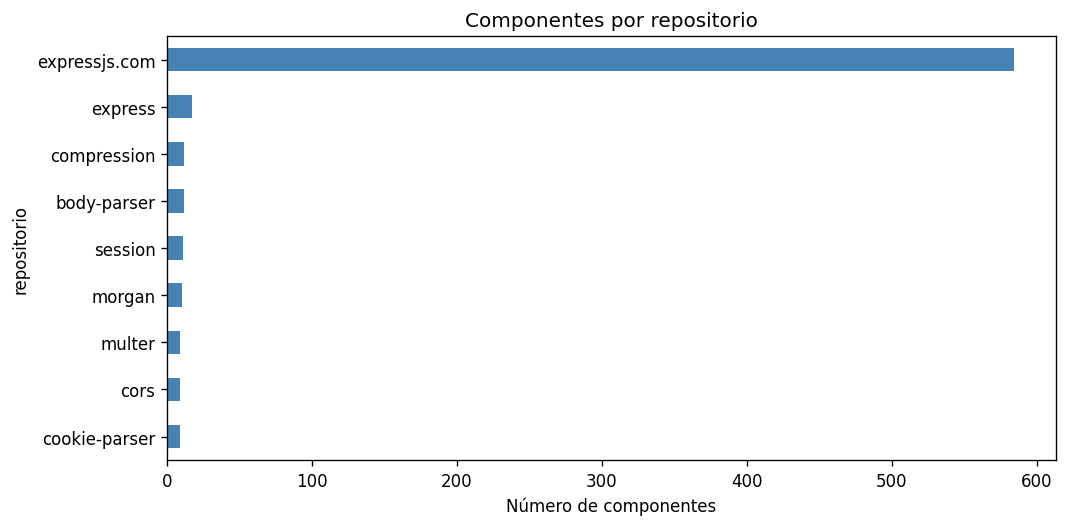

In [13]:
por_repo = df.groupby('repositorio').agg(
    total_componentes=('nombre', 'count'),
    tipos_distintos=('tipo', 'nunique'),
    lenguajes_distintos=('lenguaje', 'nunique'),
    con_licencia=('licencias', lambda x: (x != 'sin licencia').sum()),
).sort_values('total_componentes', ascending=False)

display(por_repo)

por_repo['total_componentes'].sort_values().plot(
    kind='barh', figsize=(9, max(3, len(por_repo) * 0.5)), color='steelblue'
)
plt.title('Componentes por repositorio')
plt.xlabel('Número de componentes')
plt.tight_layout()
plt.show()

## 5. Categorías de tipos por repositorio (stacked)

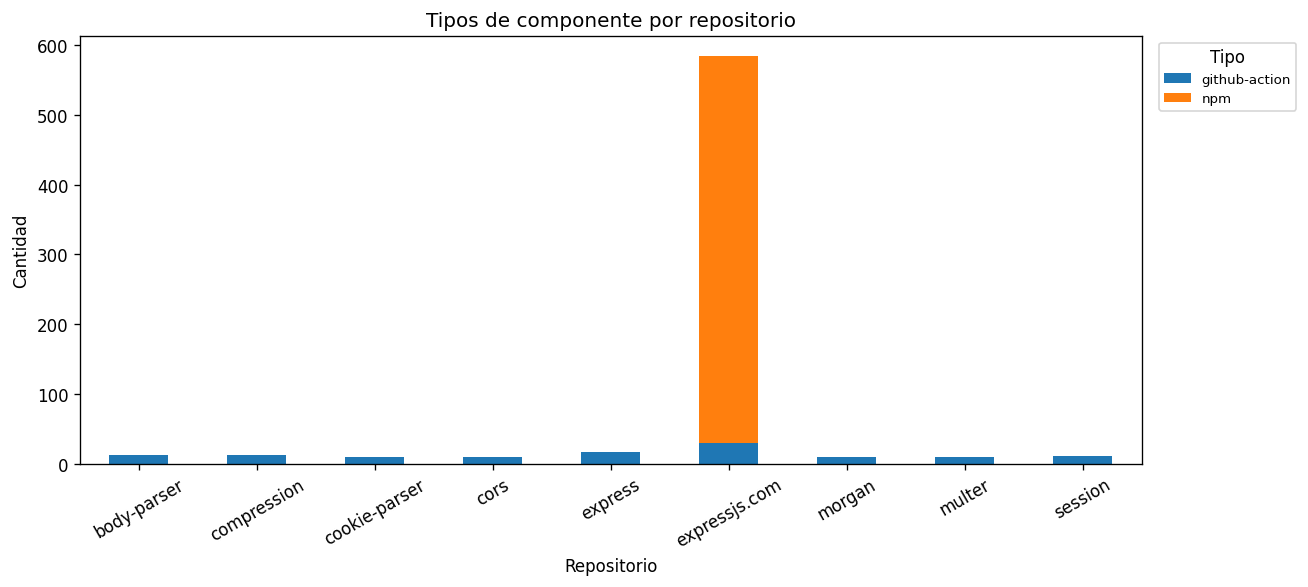

In [14]:
pivot_tipo = df.pivot_table(
    index='repositorio', columns='tipo', values='nombre',
    aggfunc='count', fill_value=0
)

pivot_tipo.plot(kind='bar', stacked=True, figsize=(11, 5))
plt.title('Tipos de componente por repositorio')
plt.ylabel('Cantidad')
plt.xlabel('Repositorio')
plt.legend(title='Tipo', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Análisis de licencias

Top 15 licencias:
licencia
MIT                                         412
Apache-2.0                                   16
ISC                                          14
BSD-2-Clause                                 12
LGPL-3.0-or-later                            10
BlueOak-1.0.0                                 6
BSD-3-Clause                                  4
Apache-2.0 AND LGPL-3.0-or-later              3
CC0-1.0                                       3
AGPL-3.0                                      2
Apache-2.0 AND LGPL-3.0-or-later AND MIT      1
Python-2.0                                    1
CC-BY-SA-4.0                                  1
MPL-2.0                                       1
0BSD                                          1


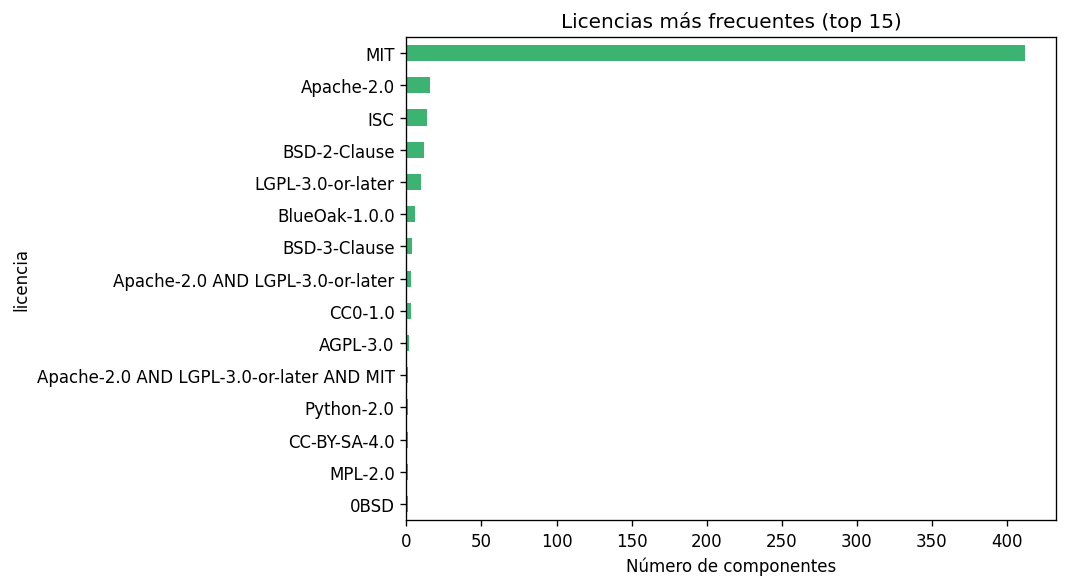

In [15]:
# Expandir múltiples licencias por componente
lic_expandidas = []
for _, row in df.iterrows():
    for lic in row['licencias'].split(', '):
        lic_expandidas.append({'repositorio': row['repositorio'], 'licencia': lic.strip()})

df_lic = pd.DataFrame(lic_expandidas)
lic_counts = df_lic[df_lic['licencia'] != 'sin licencia']['licencia'].value_counts().head(15)

print('Top 15 licencias:')
print(lic_counts.to_string())

lic_counts.plot(kind='barh', figsize=(9, 5), color='mediumseagreen')
plt.title('Licencias más frecuentes (top 15)')
plt.xlabel('Número de componentes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Catalogadores utilizados por Syft

Catalogadores Syft utilizados:
encontrado_por
javascript-lock-cataloger         555
github-actions-usage-cataloger    118


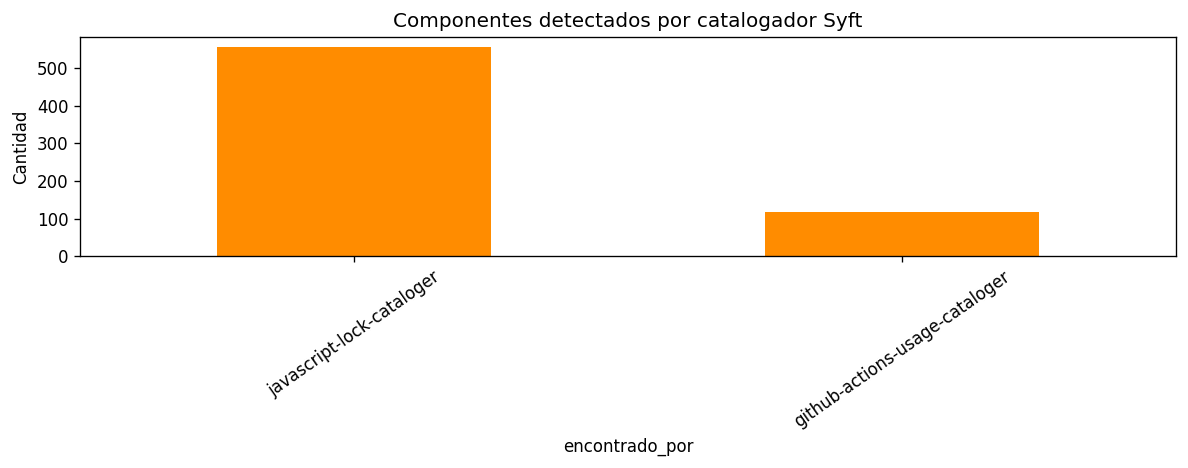

In [16]:
cat_counts = df['encontrado_por'].value_counts()
print('Catalogadores Syft utilizados:')
print(cat_counts.to_string())

cat_counts.plot(kind='bar', figsize=(10, 4), color='darkorange')
plt.title('Componentes detectados por catalogador Syft')
plt.ylabel('Cantidad')
plt.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()